In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('P675 DATASET.csv',index_col='Date',parse_dates=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
...,...,...,...,...,...,...
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300


In [3]:
df.size

12066

In [4]:
df.shape

(2011, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [6]:
# Missing values
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [7]:
# Identifying Duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
print('==Statistical Summary==\n',df.describe())

==Statistical Summary==
               Open         High          Low        Close    Adj Close  \
count  2011.000000  2011.000000  2011.000000  2011.000000  2011.000000   
mean    126.707469   127.827594   125.580258   126.741235   119.505548   
std      50.483753    50.926301    50.124940    50.578369    52.438444   
min      55.424286    57.085712    55.014286    55.790001    48.921928   
25%      85.882858    86.717858    85.056427    86.202145    75.056679   
50%     113.050003   114.190002   111.870003   113.050003   105.222908   
75%     165.190002   167.409996   163.424995   165.245002   160.047111   
max     291.119995   293.970001   288.119995   291.519989   289.522614   

             Volume  
count  2.011000e+03  
mean   5.949670e+07  
std    4.683856e+07  
min    1.136200e+07  
25%    2.758565e+07  
50%    4.346900e+07  
75%    7.471030e+07  
max    3.765300e+08  


# Feature Engineering

In [9]:
#Moving average
df['mov_avg']=df['Close'].rolling(window=30).mean()

In [10]:
# Daily returns
df['Daily_return']=df['Close'].pct_change()

In [11]:
# Volatility measures
df['Volatility']=df['Daily_return'].rolling(window=30).std()
df

,Open,High,Low,Close,Adj Close,Volume,mov_avg,Daily_return,Volatility
Date,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,NaN,NaN
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,NaN,0.005374,NaN
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,NaN,0.011102,NaN
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,NaN,0.010454,NaN
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,NaN,-0.001586,NaN
...,...,...,...,...,...,...,...,...,...
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,268.701334,0.016318,0.010186
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,269.436999,0.000951,0.010149
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,270.368667,0.019840,0.010589


* New features were created to better analyze stock trends and fluctuations.

In [12]:
# Missing values
df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
mov_avg         29
Daily_return     1
Volatility      30
dtype: int64

In [13]:
df.dropna(inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume,mov_avg,Daily_return,Volatility
Date,,,,,,,,,
2012-02-15,73.465714,75.184288,70.984283,71.095711,61.436600,376530000,63.986286,-0.023142,0.015726
2012-02-16,70.214287,72.127144,69.518570,71.744286,61.997032,236138000,64.409000,0.009123,0.015732
2012-02-17,71.872856,72.538574,71.471428,71.731430,61.985954,133951300,64.809428,-0.000179,0.015756
2012-02-21,72.411430,73.550003,72.017143,73.550003,63.557446,151398800,65.249667,0.025353,0.016123
2012-02-22,73.297142,73.641426,72.724289,73.291428,63.334015,120825600,65.684476,-0.003516,0.016162
...,...,...,...,...,...,...,...,...,...
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,268.701334,0.016318,0.010186
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,269.436999,0.000951,0.010149
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,270.368667,0.019840,0.010589


* Missing values generated from rolling calculations were removed.

# EDA and Visualzation

In [14]:
#closing price trend visualization

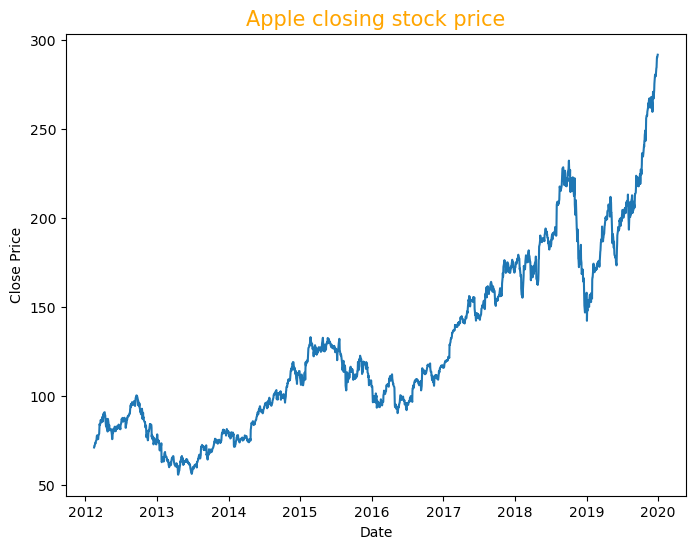

In [15]:
plt.figure(figsize=(8,6))
plt.plot(df['Close'])
plt.title('Apple closing stock price',fontsize=15,color='Orange')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

* The stock price shows an overall upward trend over time.

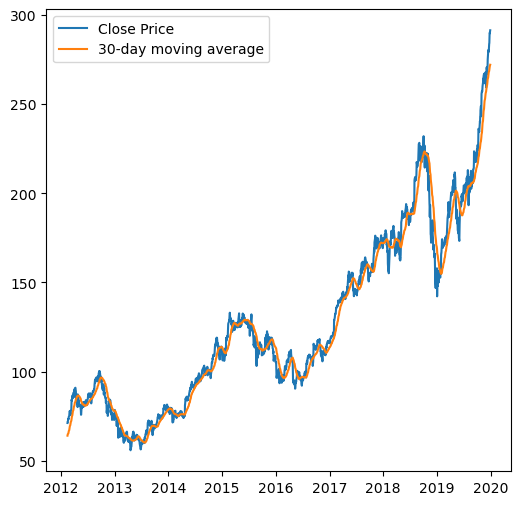

In [16]:
# Moving average visualization
plt.figure(figsize=(6,6))
plt.plot(df['Close'],label='Close Price')
plt.plot(df['mov_avg'],label='30-day moving average')
plt.legend()
plt.show()

* The moving average helps identify the long-term stock trend.

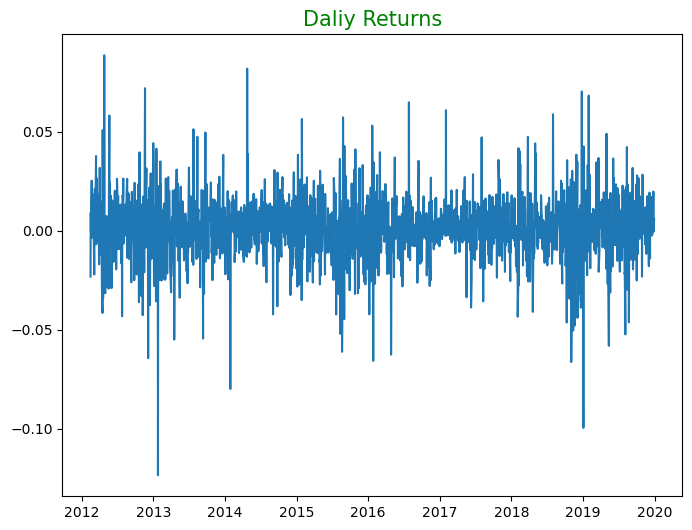

In [17]:
# Plot Daily returns
plt.figure(figsize=(8,6))
plt.plot(df['Daily_return'])
plt.title('Daliy Returns',fontsize=15,color='Green')
plt.show()

* Daily returns show both positive and negative stock movements.

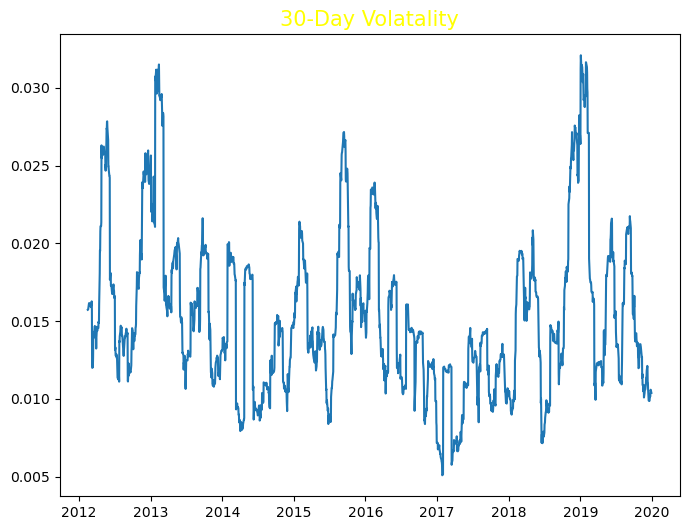

In [18]:
# Plot Volatility
plt.figure(figsize=(8,6))
plt.plot(df['Volatility'])
plt.title('30-Day Volatality',fontsize=15,color='yellow')
plt.show()

* Some periods show higher stock market volatility than others.

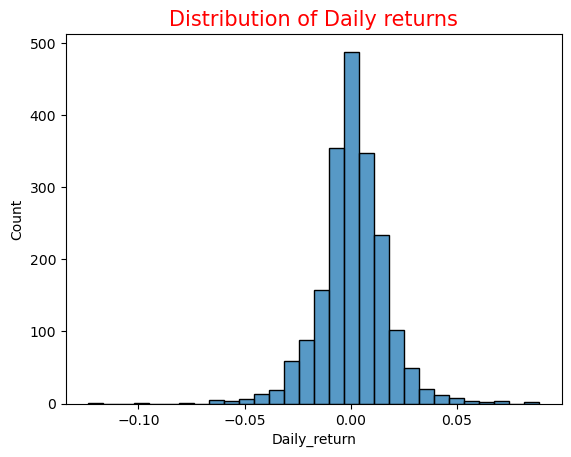

In [19]:
# Histogram
sns.histplot(df['Daily_return'],bins=30)
plt.title('Distribution of Daily returns',fontsize=15,color='red')
plt.show()

* Most daily returns are concentrated near zero.

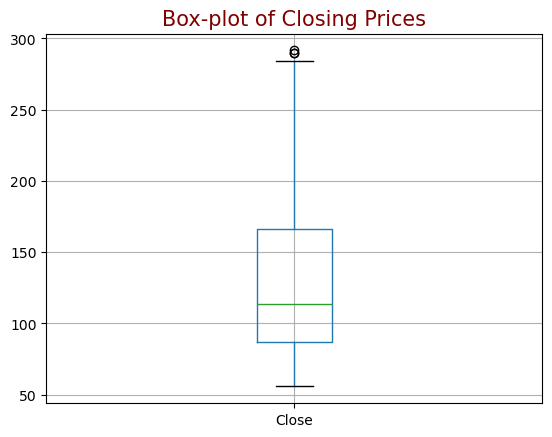

In [20]:
# Boxplot
df[['Close']].boxplot()
plt.title('Box-plot of Closing Prices',fontsize=15,color='maroon')
plt.show()

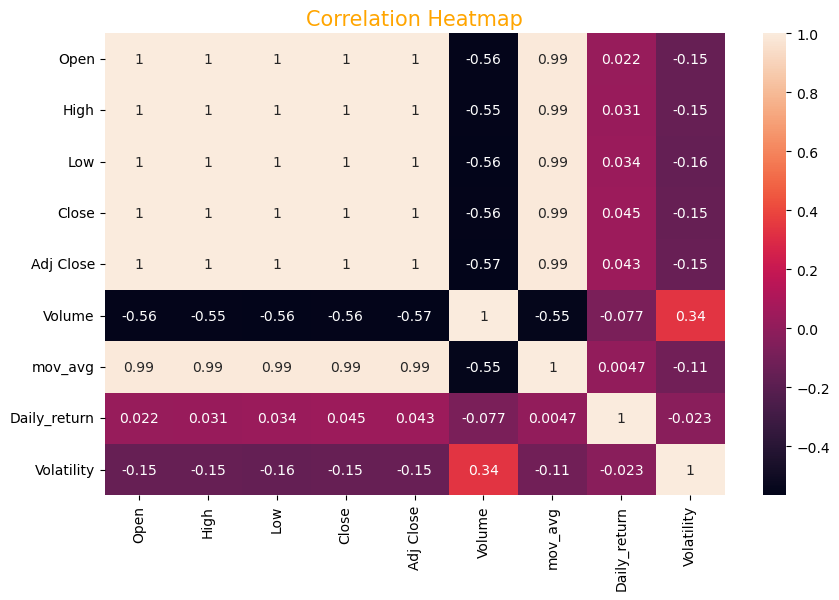

In [21]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap',fontsize=15,color='Orange')
plt.show()

In [22]:
# First Order Differencing
from statsmodels.tsa.stattools import adfuller
df['First_ord_diff']=df['Close'].diff()

* Price-related features are highly correlated with each other.

In [23]:
# First Order Differencing
from statsmodels.tsa.stattools import adfuller
df['First_ord_diff']=df['Close'].diff()
#Remove missing values created by differencing
df.dropna(inplace=True)

#ADF Test
result = adfuller(df['First_ord_diff'])

#Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Decision
if result[1] < 0.05:
    print("Data is Stationary after differencing")
else:
    print("Data is Still Non-Stationary")

ADF Statistic: -13.555801633724192
p-value: 2.361318175149154e-25
Data is Stationary after differencing


In [24]:
df.isnull().sum()

Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
mov_avg           0
Daily_return      0
Volatility        0
First_ord_diff    0
dtype: int64

* First order differencing helps remove trend from the stock price data and makes the time series more stationary for forecasting analysis.

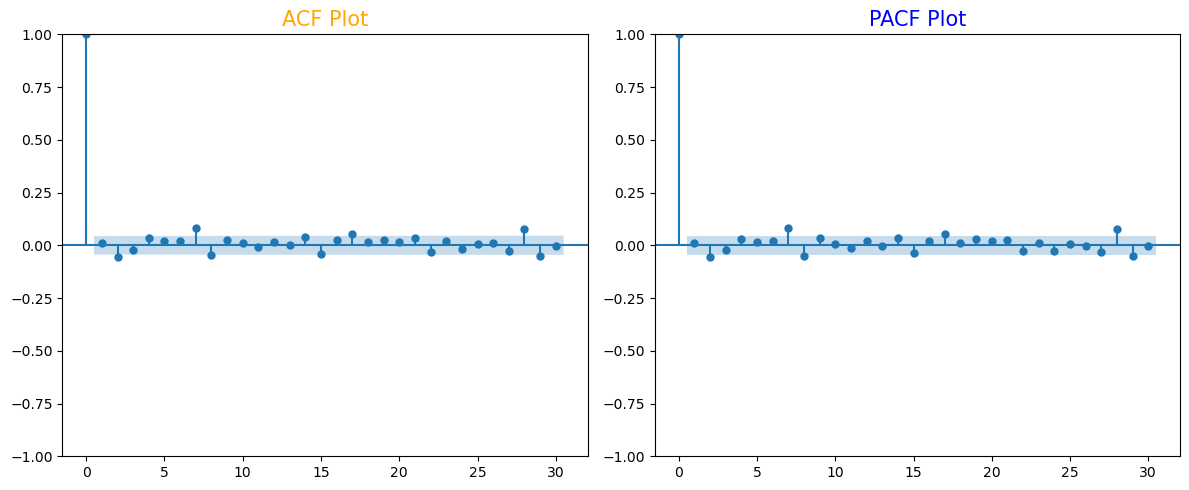

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

# ACF Plot
plt.subplot(1,2,1)
plot_acf(df['First_ord_diff'].dropna(),ax=plt.gca(),lags=30)
plt.title('ACF Plot',fontsize=15,color='orange')

#PACF Plot
plt.subplot(1,2,2)
plot_pacf(df['First_ord_diff'].dropna(),ax=plt.gca(),lags=30)
plt.title('PACF Plot',fontsize=15,color='blue')

plt.tight_layout()

* The **ACF plot** shows strong correlation between current and past stock prices across several lags.
* The **PACF plot** helps identify significant lag values useful for ARIMA modeling.

# Model Building

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Seperating features and target
features=df.drop(columns='Close')
target=df[['Close']]

#Train test split

In [28]:
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.2,shuffle=False)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1584, 9)
(396, 9)
(1584, 1)
(396, 1)


# 1) ARIMA Model

In [29]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [30]:
model=ARIMA(y_train,order=(1,1,1))
model_fit=model.fit()
print(model_fit.summary())

C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1584
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3045.824
Date:                Mon, 29 Jun 2026   AIC                           6097.647
Time:                        20:14:52   BIC                           6113.748
Sample:                             0   HQIC                          6103.629
                               - 1584                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2899      0.388     -0.747      0.455      -1.051       0.471
ma.L1          0.3376      0.384      0.879      0.379      -0.415       1.090
sigma2         2.7464      0.058     47.544      0.0

In [31]:
# Forecasting
forecast=model_fit.forecast(steps=len(y_test))
print(forecast)

1584    191.848300
1585    191.842995
1586    191.844533
1587    191.844087
1588    191.844216
           ...    
1975    191.844187
1976    191.844187
1977    191.844187
1978    191.844187
1979    191.844187
Name: predicted_mean, Length: 396, dtype: float64


C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MSE: 1078.0119485821556
MAE: 24.548883114266765
RMSE: 32.83309227870801


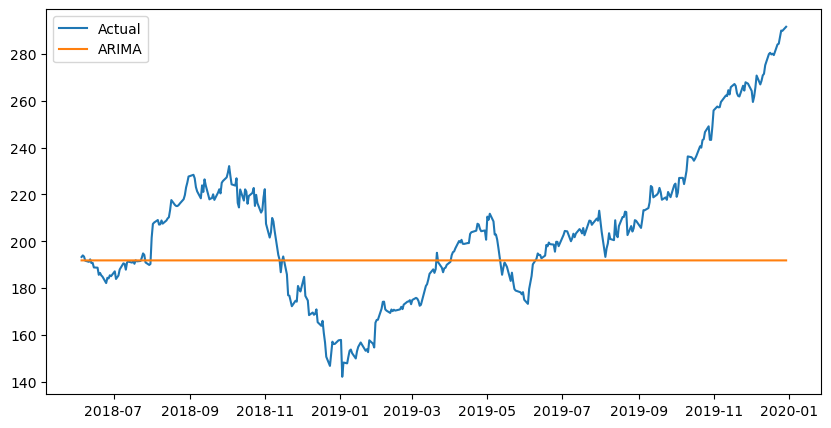

In [32]:
# Evaluation
arima_mse = mean_squared_error(y_test,forecast)
arima_mae = mean_absolute_error(y_test,forecast)
arima_rmse = np.sqrt(arima_mse)

print("MSE:", arima_mse)
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test['Close'], label='Actual')
plt.plot(y_test.index,forecast, label='ARIMA')
plt.legend()

# 2)SARIMA Model

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [34]:
sarima=SARIMAX(y_train,order=(1,1,1),seasonal_order=(1,1,1,5))
sarima_fit=sarima.fit()
print(sarima_fit.summary())

C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                 1584
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood               -3051.066
Date:                           Mon, 29 Jun 2026   AIC                           6112.132
Time:                                   20:14:58   BIC                           6138.952
Sample:                                        0   HQIC                          6122.098
                                          - 1584                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3073      0.399     -0.770      0.442      -1.090       0.475
ma.L1          0.3538      0.395      0.897

In [35]:
# Forecasting
sarima_forecast=sarima_fit.forecast(steps=len(y_test))
print(sarima_forecast)

1584    191.903327
1585    192.003862
1586    192.065866
1587    192.157066
1588    192.184603
           ...    
1975    221.520662
1976    221.572636
1977    221.705061
1978    221.751900
1979    221.800789
Name: predicted_mean, Length: 396, dtype: float64


C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MSE: 719.1163786881
MAE: 21.487383385821445
RMSE 26.816345364126335


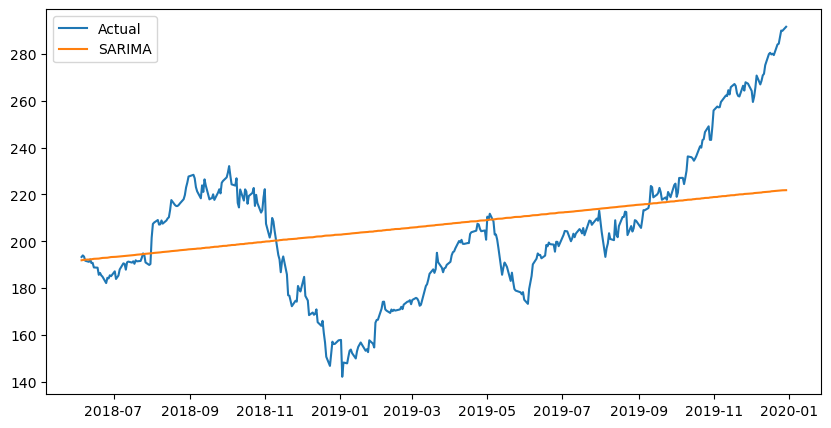

In [36]:
# Evaluation
sarima_mse=mean_squared_error(y_test,sarima_forecast)
sarima_mae=mean_absolute_error(y_test,sarima_forecast)
sarima_rmse=np.sqrt(sarima_mse)

print('MSE:',sarima_mse)
print('MAE:',sarima_mae)
print('RMSE',sarima_rmse)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, sarima_forecast, label='SARIMA')
plt.legend()
plt.show()

# Creating Lag Features

In [37]:
df_ml=df.copy()

df_ml['Lag1']=df_ml['Close'].shift(1)
df_ml['Lag2']=df_ml['Close'].shift(2)
df_ml['Lag3']=df_ml['Close'].shift(3)

# After creating lag features ,we have got some missing values and they were removed below.
df_ml.dropna(inplace=True)

# Insights

- Lag features were created to provide previous stock price information to the machine learning models.
- **Lag1**, **Lag2**, and **Lag3** represent stock prices from the previous 1, 2, and 3 trading days.
- Random Forest and XGBoost cannot automatically understand time order like ARIMA and SARIMA.
- Lag features help capture short-term trends and temporal dependencies in stock prices.
- Previous stock prices were used as input features to improve the forecasting performance of Random Forest and XGBoost models.

In [38]:
df_ml.head()

,Open,High,Low,Close,Adj Close,Volume,mov_avg,Daily_return,Volatility,First_ord_diff,Lag1,Lag2,Lag3
Date,,,,,,,,,,,,,
2012-02-22,73.297142,73.641426,72.724289,73.291428,63.334015,120825600,65.684476,-0.003516,0.016162,-0.258575,73.550003,71.731430,71.744286
2012-02-23,73.582855,73.975716,72.785713,73.769997,63.747555,142006900,66.128047,0.006530,0.016151,0.478569,73.291428,73.550003,71.731430
2012-02-24,74.238571,74.699997,74.091431,74.629997,64.490730,103768000,66.603571,0.011658,0.016095,0.860000,73.769997,73.291428,73.550003
2012-02-27,74.472855,75.500000,73.754288,75.108574,64.904282,136895500,67.100571,0.006413,0.015986,0.478577,74.629997,73.769997,73.291428
2012-02-28,75.422859,76.487144,75.121429,76.487144,66.095551,150096800,67.651048,0.018354,0.015958,1.378570,75.108574,74.629997,73.769997


In [39]:
# Again define X and Y now 
X=df_ml[['Lag1','Lag2','Lag3']] #Lag1,Lag2,...are Previous prices
Y=df_ml[['Close']]              # Current price

# Train test Split

In [40]:
x_train_new,x_test_new,y_train_new,y_test_new=train_test_split(X,Y,test_size=0.2,shuffle=False)
print(x_train_new.shape)
print(y_train_new.shape)
print(x_test_new.shape)
print(y_test_new.shape)

(1581, 3)
(1581, 1)
(396, 3)
(396, 1)


# 3) Random Forest

In [41]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=100)
rf_model.fit(x_train_new,y_train_new)
rf_pred=rf_model.predict(x_test_new)

MSE: 1010.3605629666876
MAE: 21.01060672368689
RMSE: 31.786169366041698


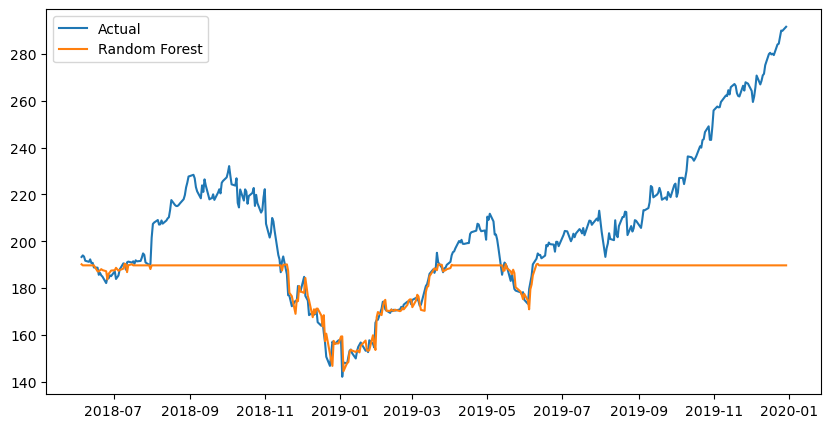

In [43]:
# Evaluation
rf_mse=mean_squared_error(y_test_new,rf_pred)
rf_mae=mean_absolute_error(y_test_new,rf_pred)
rf_rmse=np.sqrt(rf_mse)

print('MSE:',rf_mse)
print('MAE:',rf_mae)
print('RMSE:',rf_rmse)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test_new.index, y_test_new, label='Actual')
plt.plot(y_test_new.index, rf_pred, label='Random Forest')
plt.legend()
plt.show()

# 4) XGBoost Model

In [44]:
from xgboost import XGBRFRegressor

In [45]:
xgb=XGBRFRegressor(learning_rate=0.9,subsample=0.8)
xgb.fit(x_train_new,y_train_new)
xgb_pred=xgb.predict(x_test_new)

MSE: 1492.0306396484375
MAE: 29.113636016845703
RMSE: 38.626812444834705


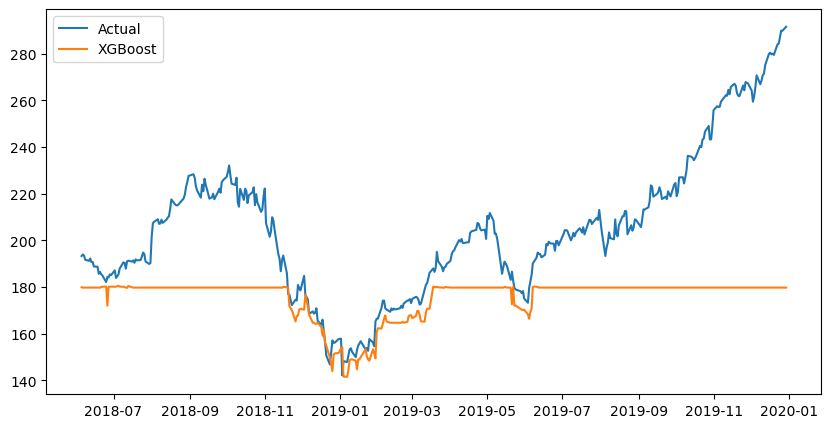

In [46]:
# Evaluation
xgb_mse=mean_squared_error(y_test_new,xgb_pred)
xgb_mae=mean_absolute_error(y_test_new,xgb_pred)
xgb_rmse=np.sqrt(xgb_mse)

print('MSE:',xgb_mse)
print('MAE:',xgb_mae)
print('RMSE:',xgb_rmse)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test_new.index,y_test_new,label='Actual')
plt.plot(y_test_new.index,xgb_pred,label='XGBoost')
plt.legend()
plt.show()

In [47]:
# Finding the best model using comparsion
results={
    'MSE':[arima_mse,sarima_mse,rf_mse,xgb_mse],
    'MAE':[arima_mae,sarima_mae,rf_mae,xgb_mae],
    'RMSE':[arima_rmse,sarima_rmse,rf_rmse,xgb_rmse]}

In [48]:
best_model=pd.DataFrame(results,index=['ARIMA','SARIMA','Random Forest','XGBoost'])
best_model.sort_values(by='RMSE',ascending=True)

,MSE,MAE,RMSE
SARIMA,719.116379,21.487383,26.816345
Random Forest,1010.360563,21.010607,31.786169
ARIMA,1078.011949,24.548883,32.833092
XGBoost,1492.030640,29.113636,38.626812


**SARIMA is the best model with less errors compared to other models.**

# Hyperparameter Tuning

In [49]:
p = [0,1,2]
d = [1,2]
q = [0,1,2]

best_rmse = float('inf')
best_order = None

for i in p:
    for j in d:
        for k in q:

            try:
                model = SARIMAX(y_train,order=(i,j,k),seasonal_order=(1,1,1,5))

                fit_model = model.fit(disp=False)

                pred = fit_model.forecast(steps=len(y_test))

                rmse = np.sqrt(mean_squared_error(y_test, pred))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (i,j,k)

            except:
                continue

print("Best Order:", best_order)
print("Best RMSE:", best_rmse)

C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.


Best Order: (2, 1, 0)
Best RMSE: 26.810046497534486


C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [50]:
# SARIMA model after finding the best parameters using tuning method.
final_model = SARIMAX(df['Close'],order=(2,1,0),seasonal_order=(1,1,1,5))
final_fit = final_model.fit()

C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [51]:
# Future 30-Day Forecasting
future_30 = final_fit.forecast(steps=30)
print(future_30)#Here we got index

1980    291.860656
1981    291.783193
1982    292.034935
1983    292.130777
1984    292.291121
1985    292.501265
1986    292.505571
1987    292.632912
1988    292.728610
1989    292.851926
1990    293.059267
1991    293.065518
1992    293.189907
1993    293.285601
1994    293.408043
1995    293.615318
1996    293.621615
1997    293.745934
1998    293.841628
1999    293.964050
2000    294.171323
2001    294.177621
2002    294.301939
2003    294.397632
2004    294.520054
2005    294.727327
2006    294.733625
2007    294.857943
2008    294.953637
2009    295.076058
Name: predicted_mean, dtype: float64


C:\Users\S Tharun Kumar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [52]:
# To get next 30 days dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='B'
)

future_30 = pd.Series(future_30.values, index=future_dates)

print(future_30)

2019-12-31    291.860656
2020-01-01    291.783193
2020-01-02    292.034935
2020-01-03    292.130777
2020-01-06    292.291121
2020-01-07    292.501265
2020-01-08    292.505571
2020-01-09    292.632912
2020-01-10    292.728610
2020-01-13    292.851926
2020-01-14    293.059267
2020-01-15    293.065518
2020-01-16    293.189907
2020-01-17    293.285601
2020-01-20    293.408043
2020-01-21    293.615318
2020-01-22    293.621615
2020-01-23    293.745934
2020-01-24    293.841628
2020-01-27    293.964050
2020-01-28    294.171323
2020-01-29    294.177621
2020-01-30    294.301939
2020-01-31    294.397632
2020-02-03    294.520054
2020-02-04    294.727327
2020-02-05    294.733625
2020-02-06    294.857943
2020-02-07    294.953637
2020-02-10    295.076058
Freq: B, dtype: float64


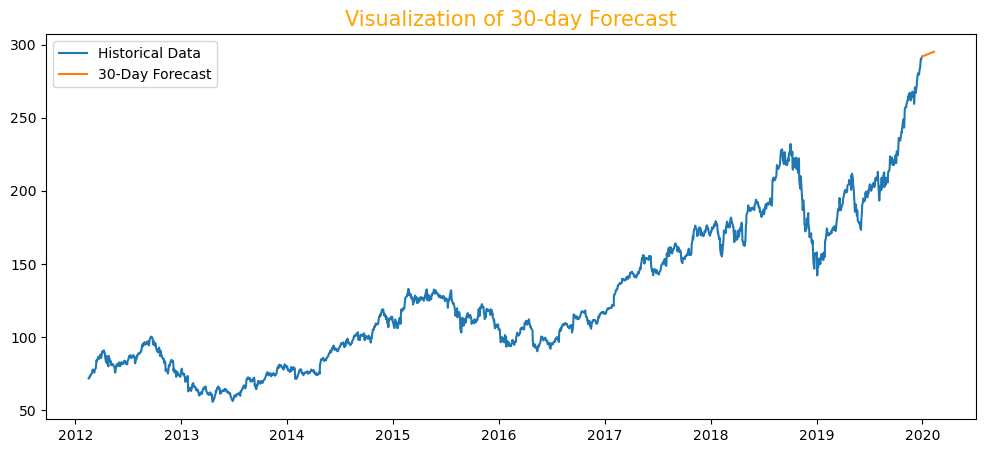

In [53]:
# Visualization of Forecast
plt.figure(figsize=(12,5))

plt.plot(df['Close'], label='Historical Data')
plt.plot(future_30, label='30-Day Forecast')
plt.title('Visualization of 30-day Forecast',fontsize=15,color='Orange')

plt.legend()

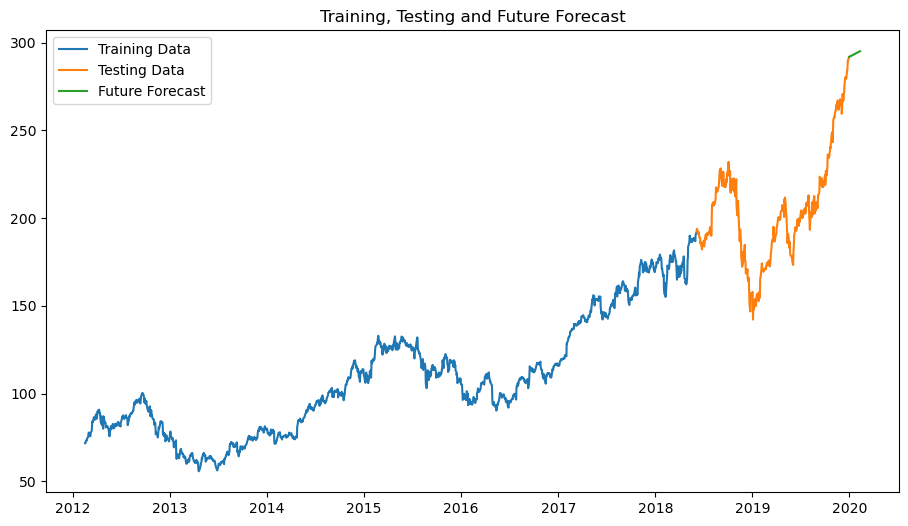

In [54]:
# Training, Testing and Future Forecast visualization
plt.figure(figsize=(11,6))

plt.plot(y_train,label='Training Data')
plt.plot(y_test,label='Testing Data')
plt.plot(future_30,label='Future Forecast')

plt.title('Training, Testing and Future Forecast')
plt.legend()

In [55]:
# Pickle file
file='Apple_project.pkl'

In [56]:
#import pickle
#pickle.dump(final_model,open(file,'wb'))
# If we use pickle file,we can't able to upload pickle file in github because its taking more storage,hence we are doing compression with joblib otherwise we can use pickle file itself for normal projects.

In [57]:
import joblib
joblib.dump(final_model, file, compress=3)

['Apple_project.pkl']